In [2]:
import xarray as xr
import matplotlib.pyplot as plt

# Reanalysis

In [3]:
RA_reg_ds = xr.open_dataset('/glade/work/acruz/Reanalysis/wind_regression.nc')
RA_reg_ds

<xarray.Dataset> Size: 955kB
Dimensions:        (level: 37, lon: 801)
Coordinates:
  * lon            (lon) float64 6kB -180.0 -179.8 -179.5 ... 19.5 19.75 20.0
  * level          (level) float64 296B 1.0 2.0 3.0 5.0 ... 950.0 975.0 1e+03
Data variables:
    U_EANI_slope   (level, lon) float32 119kB ...
    U_EANI_pvalue  (level, lon) float32 119kB ...
    W_EANI_slope   (level, lon) float32 119kB ...
    W_EANI_pvalue  (level, lon) float32 119kB ...
    U_CANI_slope   (level, lon) float32 119kB ...
    U_CANI_pvalue  (level, lon) float32 119kB ...
    W_CANI_slope   (level, lon) float32 119kB ...
    W_CANI_pvalue  (level, lon) float32 119kB ...
Attributes:
    Description:  Linear regression results from ERA5 wind anomalies during A...

In [4]:
# cheking for brevious bug where a worker crash would cause nans
RA_reg_ds['W_EANI_slope'].mean()

<xarray.DataArray 'W_EANI_slope' ()> Size: 8B
array(-2.1830554e-05)

In [33]:
# mask by pvalue threshold
pvt = 0.05

U_EANI_sig = RA_reg_ds['U_EANI_slope'].where(RA_reg_ds['U_EANI_pvalue'] <= pvt)
W_EANI_sig = RA_reg_ds['W_EANI_slope'].where(RA_reg_ds['W_EANI_pvalue'] <= pvt)
U_CANI_sig = RA_reg_ds['U_CANI_slope'].where(RA_reg_ds['U_CANI_pvalue'] <= pvt)
W_CANI_sig = RA_reg_ds['W_CANI_slope'].where(RA_reg_ds['W_CANI_pvalue'] <= pvt)

In [34]:
EANI_plt = xr.Dataset(
    {
        'U': U_EANI_sig,
        'W': W_EANI_sig
    })
EANI_plt

<xarray.Dataset> Size: 244kB
Dimensions:  (lon: 801, level: 37)
Coordinates:
  * lon      (lon) float64 6kB -180.0 -179.8 -179.5 -179.2 ... 19.5 19.75 20.0
  * level    (level) float64 296B 1.0 2.0 3.0 5.0 ... 925.0 950.0 975.0 1e+03
Data variables:
    U        (level, lon) float32 119kB nan nan nan ... -0.03408 -0.03329
    W        (level, lon) float32 119kB nan nan nan nan nan ... nan nan nan nan

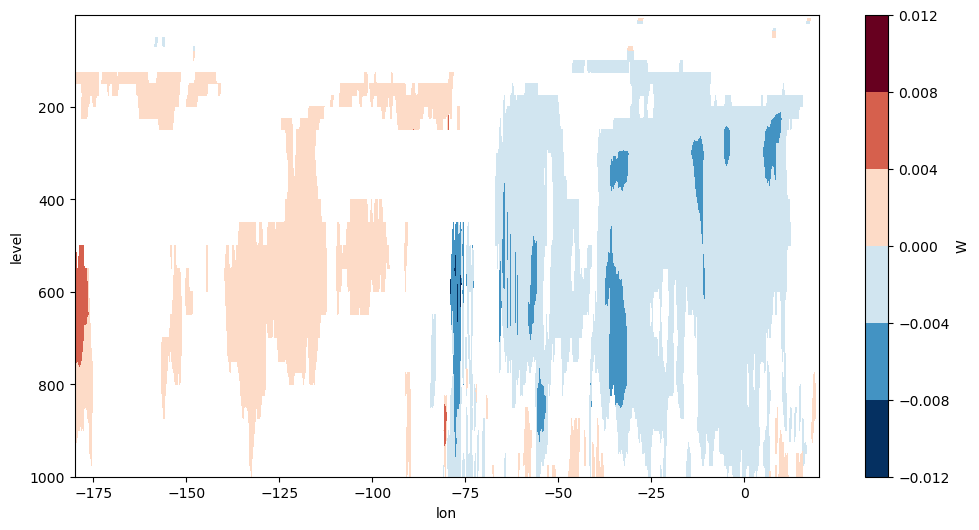

In [10]:
EANI_fig = EANI_plt['W'].plot.contourf(figsize=(12,6), yincrease=False)
EANI_fig

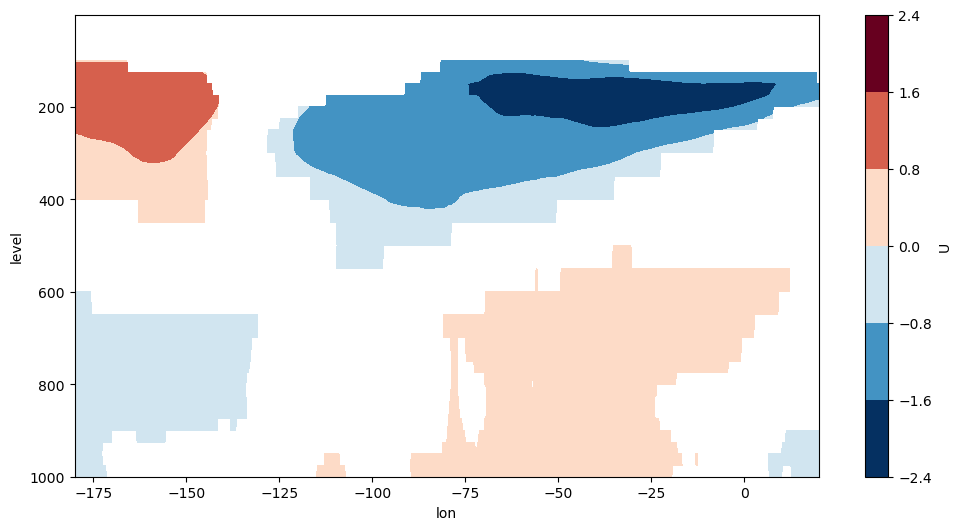

In [29]:
EANI_fig = EANI_plt['U'].plot.contourf(figsize=(12,6), yincrease=False)
EANI_fig

(1000.0, 50.0)

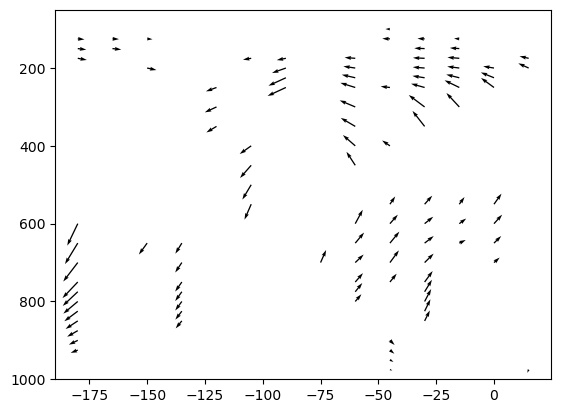

In [45]:
# plot only every nth vector, ignores the data in between
skip = {'lon': slice(None, None, 60), 'level': slice(None, None, 1)}

X_sparse = EANI_plt['lon'].isel({'lon': slice(None, None, 60)})
Y_sparse = EANI_plt['level'].isel({'level': slice(None, None, 1)})
U_sparse = EANI_plt['U'].isel(skip)
V_sparse = EANI_plt['W'].isel(skip)

plt.quiver(X_sparse, Y_sparse, U_sparse, V_sparse*1000, angles='xy')
plt.ylim([1000, 50])